# Week 4 - Informed Search (A* Search) Lab Exercises
## Exercise 7
### A. Initially will start by defining a class for the nodes.

In [1]:
import heapq
import matplotlib.pyplot as plt 
import networkx as nx

# Class representing a node in the graph 
class Node:
    def __init__(self, name, heuristic_cost): 
        self.name = name
        self.heuristic_cost = heuristic_cost 
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")
        
    def add_neighbor(self, neighbor, cost):
        self.adjacent [neighbor] = cost
    
    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost
        

### B. Define the A* algorithm.

In [2]:
# A* search algorithm
def astar_search(start, goal): 
    open_list = []
    closed_set = set()
    
    start.g_cost = 0
    heapq.heappush(open_list, start)
    
    while open_list:
        current_node = heapq.heappop (open_list)
        
        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]
        
        closed_set.add(current_node)
        
        for neighbor, cost in current_node.adjacent.items(): 
            tentative_g_cost = current_node.g_cost + cost
        
            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost: 
                continue
        
            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
                
    return None
    

### C. Then, we define our problem parameters:

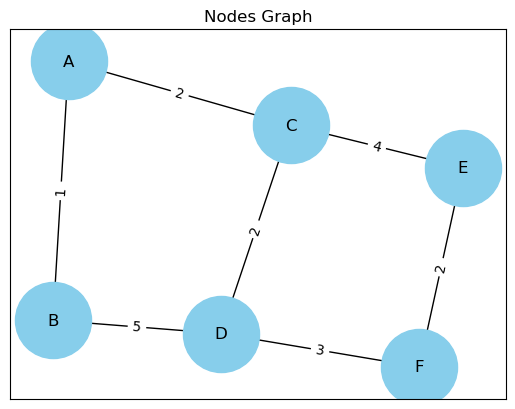

In [3]:
# Creating nodes
A = Node("A", 5)
B = Node("B", 4)
C = Node("C", 3)
D = Node("D", 2)
E = Node("E", 1)
F = Node("F", 0)

# Adding neighbors and their costs
A.add_neighbor (B, 1)
A.add_neighbor (C, 2)
B.add_neighbor (D, 5)
C.add_neighbor (A, 2)
C.add_neighbor (D, 2)
C.add_neighbor (E, 4)
D.add_neighbor (F, 3)
E.add_neighbor (F, 2)

# Visualization without the solution
G = nx.Graph()
edges = [(A.name, B.name, {'weight': 1}), (A.name, C.name, {'weight': 2}), 
         (B.name, D.name, {'weight': 5}), (C.name, D.name, {'weight': 2}), 
         (C.name, E.name, {'weight': 4}), (D.name, F.name, {'weight': 3}), 
         (E.name, F.name, {'weight': 2})]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels (G, pos, edge_labels=labels)

plt.title('Nodes Graph')
plt.show()

### D. Now we have defined all the necessary parts we can run the A* algorithm and get the results.

In [4]:
# Running the A* search algorithm 
path = astar_search(A, F) 
print("A* path:", path)

A* path: ['A', 'C', 'D', 'F']


### E. Visualize the solution.

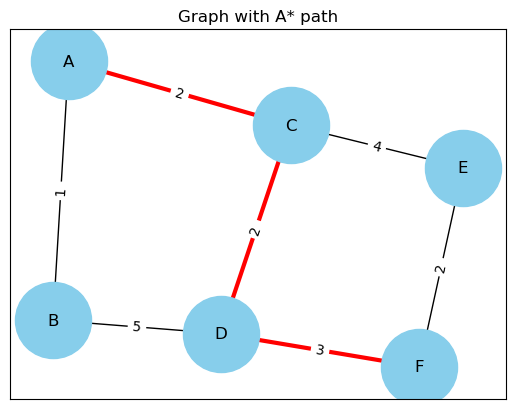

In [5]:
# Visualization with A* path 
plt.title('Graph with A* path') 
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color='skyblue') 
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=[(path[i], path[i + 1]) for i in 
              range(len(path) - 1)], edge_color='r', width=3) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) 
plt.show()

### Exercise 8: Update the script to emulate the following graph, and let the starting point be in Sunderland and the end point to be Washington.

In [6]:
# Creating nodes
A = Node("Newcastle", 5)
B = Node("South Shields", 4)
C = Node("Washington", 3) # End Point
D = Node("Sunderland", 2) # Start Point
E = Node("Durham", 1)
F = Node("Peterlee", 0)

# Fixed node positions (dictionary with node name as key and (x, y) tuple as value)
fixed_pos = {
    A.name: (1, 3),
    B.name: (1.4, 3.5),
    C.name: (1.2, 1.7),
    D.name: (1.5, 2),
    E.name: (1.1, 0),
    F.name: (1.6, 0),
}

### Exercise 9: Use a maps website to get the actual distance between cities and update your script. Find the best path to get from Sunderland to Washington.

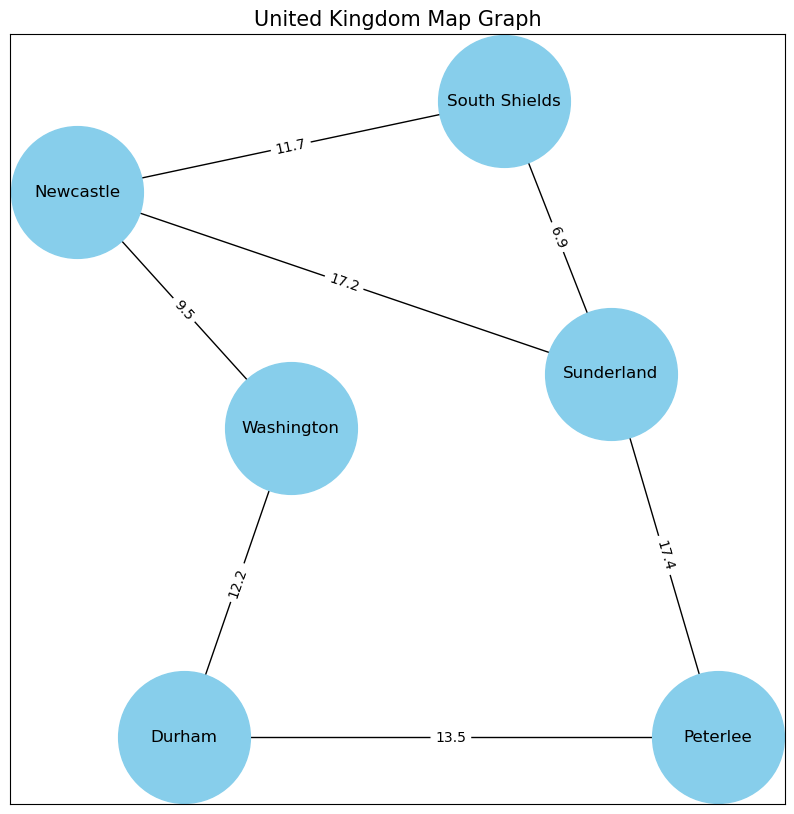

In [7]:
# Adding neighbors and their costs using Google Map
A.add_neighbor(B, 11.7)
A.add_neighbor(C, 9.5)
A.add_neighbor(D, 17.2)
B.add_neighbor(A, 11.7)
B.add_neighbor(D, 6.9)
C.add_neighbor(A, 9.5)
C.add_neighbor(E, 12.2)
D.add_neighbor(A, 17.2)
D.add_neighbor(B, 6.9)
D.add_neighbor(F, 17.4)
E.add_neighbor(C, 12.2)
E.add_neighbor(F, 13.5)
F.add_neighbor(D, 17.4)
F.add_neighbor(E, 13.5)

# Visualization
G = nx.Graph()

edges = [(A.name, B.name, {'weight': 11.7}), (A.name, C.name, {'weight': 9.5}),
         (A.name, D.name, {'weight': 17.2}), (B.name, D.name, {'weight': 6.9}), 
         (C.name, E.name, {'weight': 12.2}), (D.name, F.name, {'weight': 17.4}), 
         (E.name, F.name, {'weight': 13.5})]

G.add_edges_from(edges) 
pos = nx.spring_layout(G, k=1, pos=fixed_pos, fixed=fixed_pos.keys())
plt.figure(figsize=(10, 10)) 

nx.draw_networkx(G, pos, with_labels=True, node_size=9000, node_color='skyblue')
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title('United Kingdom Map Graph', fontsize=15)
plt.show()


In [8]:
path = astar_search(D, C) 
print("Best path to get from Sunderland to Washington:", path)

Best path to get from Sunderland to Washington: ['Sunderland', 'Newcastle', 'Washington']


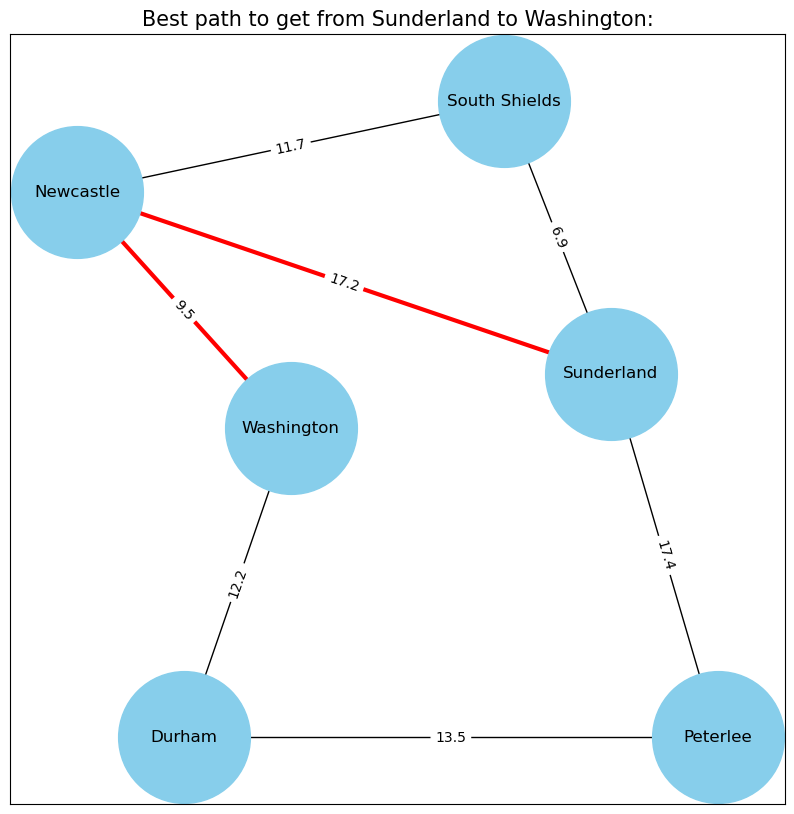

In [9]:
# Visualization
plt.figure(figsize=(10, 10)) 
plt.title('Best path to get from Sunderland to Washington:', fontsize=15)
nx.draw_networkx(G, pos, with_labels=True, node_size=9000, node_color='skyblue') 
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=[(path[i], path[i + 1]) for i in 
              range(len(path) - 1)], edge_color='r', width=3) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) 
plt.show()

### Exercise 10: Experiment with 3 different starting and ending points.

Best path to get from Durham to Sunderland: ['Durham', 'Peterlee', 'Sunderland']



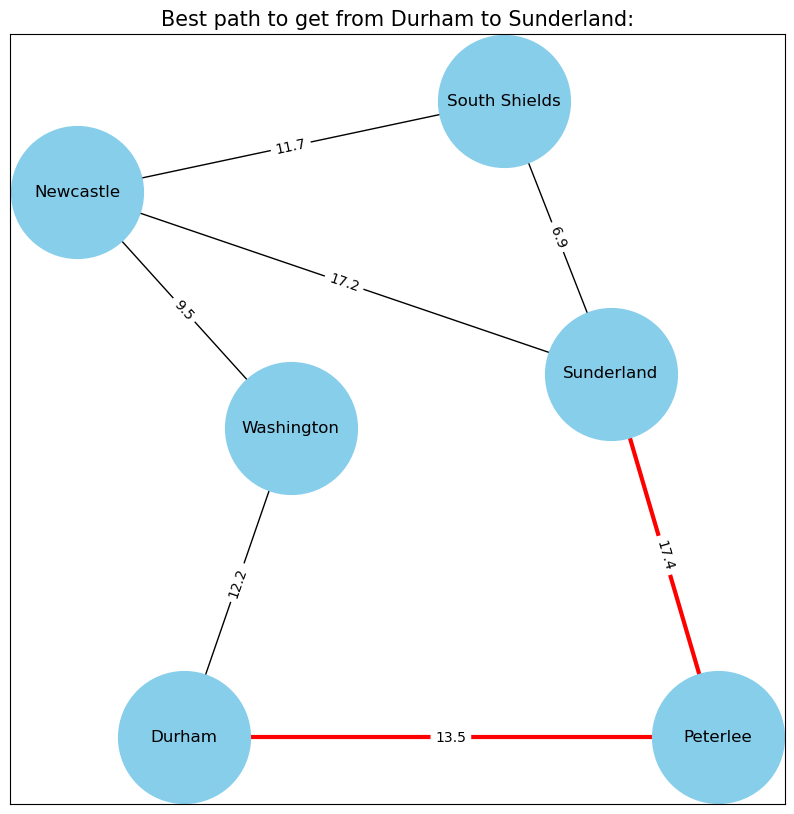

In [6]:
path = astar_search(E, D) 
print("Best path to get from Durham to Sunderland:", path)
print()

# Visualization
plt.figure(figsize=(10, 10)) 
plt.title('Best path to get from Durham to Sunderland:', fontsize=15)
nx.draw_networkx(G, pos, with_labels=True, node_size=9000, node_color='skyblue') 
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=[(path[i], path[i + 1]) for i in 
              range(len(path) - 1)], edge_color='r', width=3) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) 
plt.show()

Best path to get from Washington to Peterlee: ['Washington', 'Durham', 'Peterlee']



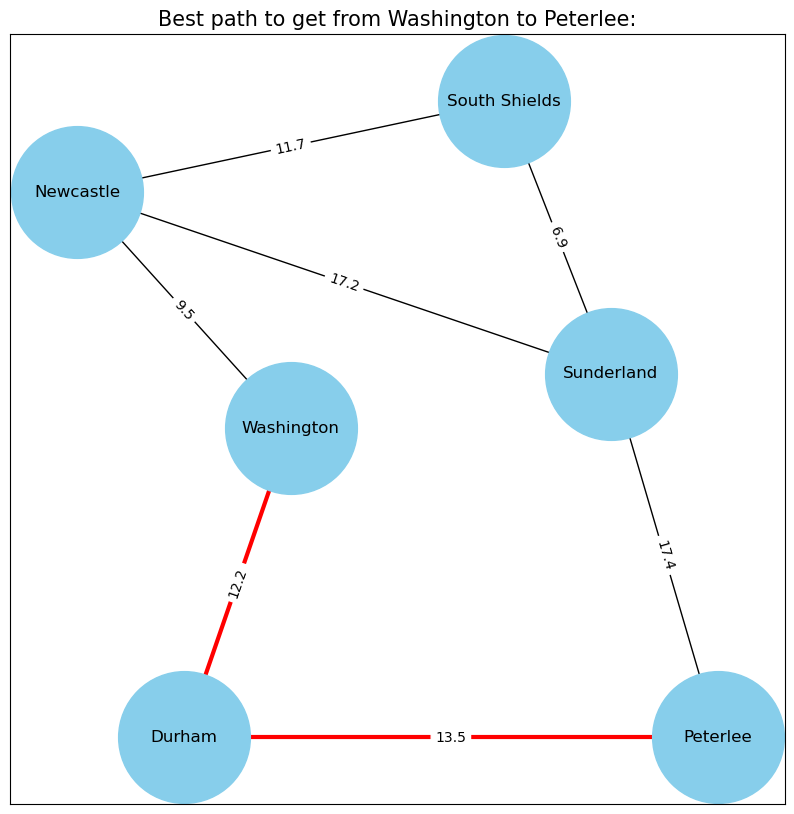

In [5]:
path = astar_search(C, F) 
print("Best path to get from Washington to Peterlee:", path)
print()

# Visualization
plt.figure(figsize=(10, 10)) 
plt.title('Best path to get from Washington to Peterlee:', fontsize=15)
nx.draw_networkx(G, pos, with_labels=True, node_size=9000, node_color='skyblue') 
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=[(path[i], path[i + 1]) for i in 
              range(len(path) - 1)], edge_color='r', width=3) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) 
plt.show()

Best path to get from South Shields to Durham: ['South Shields', 'Newcastle', 'Washington', 'Durham']



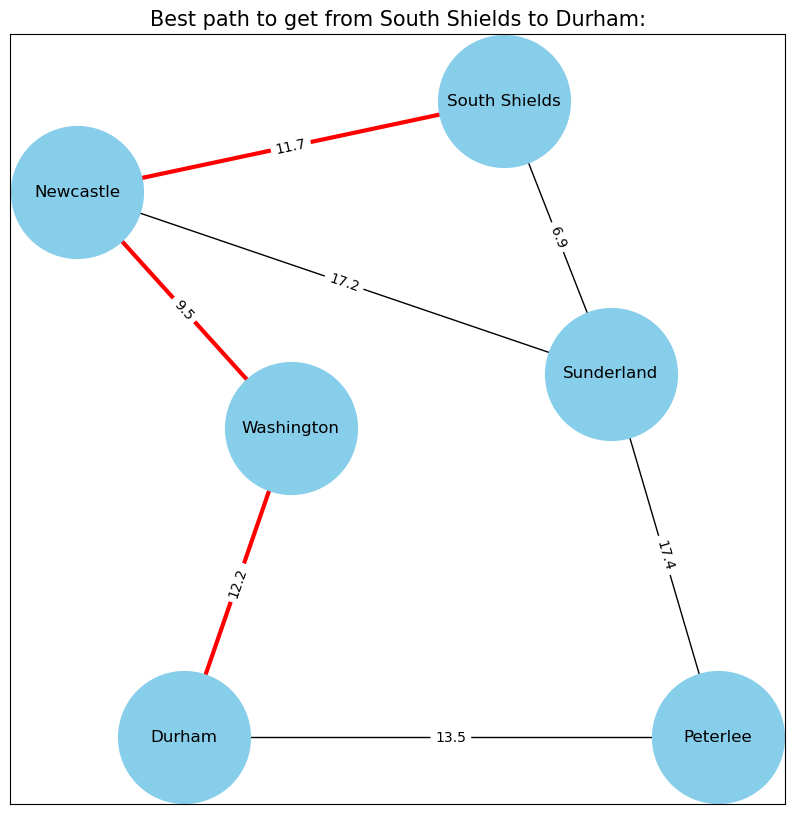

In [8]:
path = astar_search(B, E) 
print("Best path to get from South Shields to Durham:", path)
print()

# Visualization
plt.figure(figsize=(10, 10)) 
plt.title('Best path to get from South Shields to Durham:', fontsize=15)
nx.draw_networkx(G, pos, with_labels=True, node_size=9000, node_color='skyblue') 
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=[(path[i], path[i + 1]) for i in 
              range(len(path) - 1)], edge_color='r', width=3) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels) 
plt.show()